In [3]:
%pylab widget
%load_ext autoreload
%autoreload 2

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [4]:
# Read the mhd file from data
from fastcat import patient_data
import fastcat as fc

In [7]:
nrrd_file = '/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Stereo_CNS_Scan.nrrd'
fc.utils.nrrd_to_mhd(nrrd_file,force=True)

[2024-03-29 13:51:39,073] {utils.py:494} INFO - Directory 2_Stereo_CNS_Scan already exists, but is being overwriten


[2024-03-29 13:51:40,194] {utils.py:575} INFO - The spacing is [1.25     0.761719 0.761719]
[2024-03-29 13:51:40,195] {utils.py:577} INFO - The origin is [-229.5 -195.  -195. ]
[2024-03-29 13:51:40,195] {utils.py:578} INFO - The shape is (296, 512, 512)
[2024-03-29 13:51:42,258] {utils.py:368} INFO - Loading density data from file
[2024-03-29 13:51:42,262] {utils.py:706} INFO -     Saved SchneiderMaterialsWeight1 atten to file in data/mu_over_rho/SchneiderMaterialsWeight1.csv
[2024-03-29 13:51:42,263] {utils.py:368} INFO - Loading density data from file
[2024-03-29 13:51:42,265] {utils.py:706} INFO -     Saved SchneiderMaterialsWeight2 atten to file in data/mu_over_rho/SchneiderMaterialsWeight2.csv
[2024-03-29 13:51:42,266] {utils.py:368} INFO - Loading density data from file
[2024-03-29 13:51:42,268] {utils.py:706} INFO -     Saved SchneiderMaterialsWeight3 atten to file in data/mu_over_rho/SchneiderMaterialsWeight3.csv
[2024-03-29 13:51:42,269] {utils.py:368} INFO - Loading density d

In [11]:
phantom = patient_data.patient_phantom(nrrd_file, 1e8)

[2024-03-29 14:03:50,901] {utils.py:107} INFO - Using default geometry, DSD = 1510, nDetector = [512, 512], dDetector = [0.784, 0.784]
[2024-03-29 14:03:50,902] {utils.py:368} INFO - Loading density data from file
[2024-03-29 14:03:50,903] {utils.py:421} INFO - Making attenuation files in gecco:
[2024-03-29 14:03:50,903] {utils.py:426} INFO -     Air atten file already exists, skipping...
[2024-03-29 14:03:50,903] {utils.py:426} INFO -     polyurethane atten file already exists, skipping...
[2024-03-29 14:03:50,903] {utils.py:426} INFO -     teflon atten file already exists, skipping...
[2024-03-29 14:03:50,904] {utils.py:426} INFO -     pmp atten file already exists, skipping...
[2024-03-29 14:03:50,904] {utils.py:426} INFO -     bone50 atten file already exists, skipping...
[2024-03-29 14:03:50,904] {utils.py:426} INFO -     ldpe atten file already exists, skipping...
[2024-03-29 14:03:50,904] {utils.py:426} INFO -     polystyrene atten file already exists, skipping...
[2024-03-29 14

In [17]:
spec = fc.spectrum.calculate_spectrum_sp(120,14) # initialize the spectrum
spec.filter('Al', 4) # filter the spectrum
phantom.initialize_fastmc(1,spec)

[2024-03-29 14:10:57,324] {patient_data.py:266} INFO - Making a list of angles
[2024-03-29 14:10:57,325] {fastmc_scatter.py:68} INFO - Full fan mode - for flood field
[2024-03-29 14:10:57,328] {fastmc_scatter.py:120} INFO - Saving simulation parameters to /home/jericho/Software/fastcat/fastcat/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_simulation_28/fastmc_1e08_1angles.pkl
[2024-03-29 14:10:58,877] {fastmc_scatter.py:125} INFO - Done saving simulation parameters to /home/jericho/Software/fastcat/fastcat/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_simulation_28/fastmc_1e08_1angles.pkl
[2024-03-29 14:10:58,878] {fastmc_scatter.py:14} INFO - Full fan mode - for projections
[2024-03-29 14:10:58,879] {patient_data.py:325} INFO - 


[2024-03-29 14:10:58,879] {patient_data.py:326} INFO - Fastmc simulation initialized
[2024-03-29 14:10:58,879] {patient_data.py:327} INFO -     Output directory: /home/jericho/Software/fastcat/fastcat/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_output_28
[2024-0

In [20]:
phantom.run_fastmc(fastmc_path ='/home/jericho/Downloads/FastMC_Jan_05/FastMC_install/bin/FastMC')

[2024-03-29 14:22:24,363] {fastmc_scatter.py:144} INFO - Running fastmc_0.00.fmc
Read Parameters..../home/jericho/Software/fastcat/fastcat/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_simulation_28/fastmc_0.00.fmc
[FastMC] Reading bowtie file /home/jericho/Software/fastcat/fastcat/data/bowties/full_fan_alt.dat
[FastMC] Filter material found: Al
[FastMC] Al attenuation values loaded [43]
[FastMC] Al density: 2.699 g/cm3
[FastMC] Al filter start angle: -15 deg
[FastMC] Al thickness values: 30
Reading Materials file.../home/jericho/Software/fastcat/fastcat/data/user_phantoms/2_Stereo_CNS_Scan/2_Stereo_CNS_Scan_materials.txt
[GGEMS GGEMSVolumeCreatorManager::WriteRangeToMaterialFile](0) List of label and material:
[GGEMS GGEMSVolumeCreatorManager::WriteRangeToMaterialFile](0)     * Material: Tungsten, label: 0.000000e+00
[GGEMS GGEMSVolumeCreatorManager::WriteRangeToMaterialFile](0) List of label and material:
[GGEMS GGEMSVolumeCreatorManager::WriteRangeToMaterialFile](0)     * Material: Tu

In [53]:
phantom.load_ggems()

[2024-03-29 14:48:35,642] {patient_data.py:125} INFO - Found existing directory. Using mhd file 2_Stereo_CNS_Scan_phantom.mhd
[2024-03-29 14:48:35,643] {patient_data.py:127} INFO - Reloading phantom from pickle file 2_Stereo_CNS_Scan
[2024-03-29 14:48:35,644] {patient_data.py:145} INFO - Phantom already loaded. Reloading ggems files
[2024-03-29 14:48:35,644] {patient_data.py:160} INFO - Loading ggems files
[2024-03-29 14:48:35,645] {patient_data.py:188} INFO - Using the first detector layer ggems files
[2024-03-29 14:48:35,677] {patient_data.py:223} INFO - ggems files loaded
[2024-03-29 14:48:35,678] {patient_data.py:224} INFO -     Scatter files:
[2024-03-29 14:48:35,678] {patient_data.py:227} INFO -         /home/jericho/Software/fastcat/fastcat/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_output_28/fastmc_0.00-scatter.mhd


In [47]:
phantom.run_fastcat(1e10,2)

[2024-03-29 14:47:36,155] {patient_data.py:386} INFO - Making a list of angles
[2024-03-29 14:47:36,156] {patient_data.py:414} INFO - Detector matching specifications: CsI-784-micrometer
[2024-03-29 14:47:36,160] {ggems_simulate.py:227} INFO - Initializing filter /home/jericho/Software/fastcat/fastcat/data/bowties/full_fan_alt.dat


[2024-03-29 14:47:39,116] {ggems_simulate.py:626} INFO - Running Simulations
[2024-03-29 14:47:39,117] {ggems_simulate.py:654} INFO -     Simulating 10 keV
[2024-03-29 14:47:39,394] {ggems_simulate.py:694} INFO -       Phantom is_patient: True, using density correction
[2024-03-29 14:47:39,824] {ggems_simulate.py:654} INFO -     Simulating 20 keV
[2024-03-29 14:47:40,097] {ggems_simulate.py:694} INFO -       Phantom is_patient: True, using density correction
[2024-03-29 14:47:40,498] {ggems_simulate.py:654} INFO -     Simulating 30 keV
[2024-03-29 14:47:40,787] {ggems_simulate.py:694} INFO -       Phantom is_patient: True, using density correction
[2024-03-29 14:47:41,200] {ggems_simulate.py:654} INFO -     Simulating 40 keV
[2024-03-29 14:47:41,483] {ggems_simulate.py:694} INFO -       Phantom is_patient: True, using density correction
[2024-03-29 14:47:41,890] {ggems_simulate.py:654} INFO -     Simulating 50 keV
[2024-03-29 14:47:42,172] {ggems_simulate.py:694} INFO -       Phantom i

In [48]:
phantom.correct_intensity()

/tmp/ipykernel_25916/3848976257.py:17: RuntimeWarning: divide by zero encountered in log
  proj1 = -np.log(int1/int3)


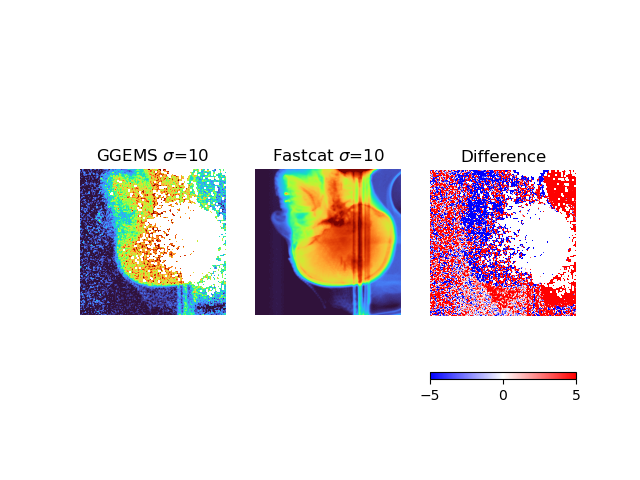

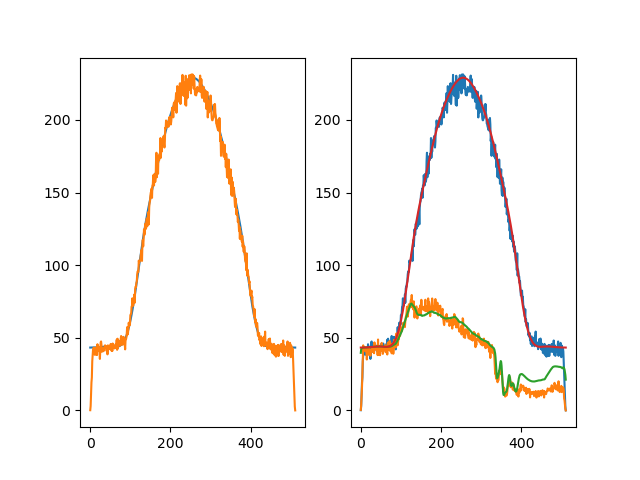

In [59]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.subplot(131)

from scipy.ndimage import gaussian_filter

filt_sigma = 1
int1 = gaussian_filter(phantom.ggems_primary_projections[0],filt_sigma)
int2 = gaussian_filter(phantom.primary_projections[0],filt_sigma)
filt_sigma = 10
int3 = gaussian_filter(np.rot90(phantom.ggems_flood),filt_sigma)
int4 = gaussian_filter(phantom.flood_field,filt_sigma)

int3[int3<1e-2] = 1e-2

proj1 = -np.log(int1/int3)
proj2 = -np.log(int2/int4)
# gaussian blur the projections using scipy ndimage 

crop = 20

plt.imshow(proj1[crop:-crop,crop:-crop],cmap='turbo',vmin=0,vmax=4)
plt.axis('off')
plt.title(f'GGEMS $\sigma$={filt_sigma}')
plt.subplot(132)
plt.imshow(proj2[crop:-crop,crop:-crop],cmap='turbo',vmin=0,vmax=4)
plt.axis('off')
plt.title(f'Fastcat $\sigma$={filt_sigma}')


# Plot the difference 
plt.subplot(133)
diff_1 = 100*(proj1[crop:-crop,crop:-crop]-proj2[crop:-crop,crop:-crop])/4
plt.axis('off')
plt.title('Difference')
plt.imshow(diff_1,cmap='bwr',vmin=-5,vmax=5)
plt.colorbar(orientation='horizontal')

# plot the mean of the difference image along both axes
#  plot the mean of the difference image along both axes
plt.figure()
plt.subplot(121)
plt.plot(np.mean(phantom.flood_field,axis=0))
plt.plot(np.mean(phantom.ggems_flood,axis=1))

plt.subplot(122)
plt.plot(np.mean(phantom.ggems_flood,axis=1))
plt.plot(np.mean(phantom.ggems_primary_projections[0],axis=0))
plt.plot(np.mean(phantom.primary_projections[0],axis=0))
plt.plot(np.mean(phantom.flood_field,axis=0))